# 02 Exploratory Data Analysis

This notebook explores the synthetic dealership lead dataset to understand which customer, enquiry and sales activity factors are associated with higher lead conversion.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/dealership_leads.csv")

df.head()

,lead_id,lead_source,customer_age_group,customer_location,vehicle_type,new_or_used,budget_range,finance_enquiry,trade_in,test_drive_completed,quote_provided,previous_customer,response_time_hours,follow_up_count,days_since_enquiry,converted
0,L0001,Walk-in,35-44,Nearby Suburb,Hatchback,Used,Medium,1,0,1,0,0,18.8,5,38,1
1,L0002,Social Media,35-44,Nearby Suburb,Sedan,New,High,0,0,0,1,1,4.0,2,20,1
2,L0003,Carsales,18-24,Local,SUV,Demo,Low,1,1,0,0,0,5.5,2,29,0
3,L0004,Carsales,25-34,Nearby Suburb,SUV,Used,Low,0,0,1,0,0,2.9,2,6,0
4,L0005,Website,25-34,Nearby Suburb,Sedan,New,Medium,1,1,0,0,0,7.2,2,9,0


In [3]:
df.shape

(1500, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   lead_id               1500 non-null   object 
 1   lead_source           1500 non-null   object 
 2   customer_age_group    1500 non-null   object 
 3   customer_location     1500 non-null   object 
 4   vehicle_type          1500 non-null   object 
 5   new_or_used           1500 non-null   object 
 6   budget_range          1500 non-null   object 
 7   finance_enquiry       1500 non-null   int64  
 8   trade_in              1500 non-null   int64  
 9   test_drive_completed  1500 non-null   int64  
 10  quote_provided        1500 non-null   int64  
 11  previous_customer     1500 non-null   int64  
 12  response_time_hours   1500 non-null   float64
 13  follow_up_count       1500 non-null   int64  
 14  days_since_enquiry    1500 non-null   int64  
 15  converted            

In [5]:
df.describe()

,finance_enquiry,trade_in,test_drive_completed,quote_provided,previous_customer,response_time_hours,follow_up_count,days_since_enquiry,converted
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.432667,0.390000,0.416667,0.493333,0.274667,11.294333,3.080667,22.668000,0.342667
std,0.495611,0.487913,0.493171,0.500122,0.446495,7.487691,1.781462,12.649972,0.474759
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,5.700000,2.000000,12.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,9.700000,3.000000,23.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,15.100000,4.000000,33.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,49.300000,11.000000,44.000000,1.000000


## Overall Conversion Rate

In [6]:
conversion_rate = df["converted"].mean()

print(f"Overall conversion rate: {conversion_rate:.2%}")

Overall conversion rate: 34.27%


In [7]:
df["converted"].value_counts()

converted
0    986
1    514
Name: count, dtype: int64

## Conversion Rate by Lead Source

Lead source is important because some channels may generate high enquiry volume but lower-quality leads.

In [8]:
lead_source_conversion = (
    df.groupby("lead_source")["converted"]
    .mean()
    .sort_values(ascending=False)
)

lead_source_conversion

lead_source
Walk-in         0.433735
Referral        0.429379
Phone           0.360731
Website         0.313283
Carsales        0.290429
Social Media    0.248366
Name: converted, dtype: float64

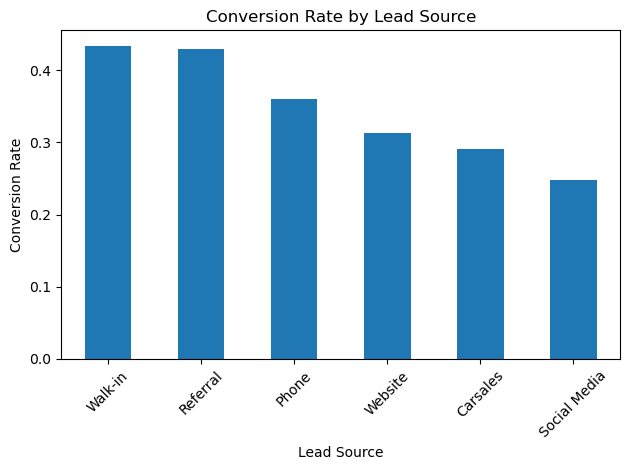

In [9]:
lead_source_conversion.plot(kind="bar")

plt.title("Conversion Rate by Lead Source")
plt.xlabel("Lead Source")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conversion by Sales Activity

This section compares conversion rates for important buying-intent signals such as test drive completion, finance enquiry, trade-in interest and quote provided.

In [10]:
activity_features = [
    "test_drive_completed",
    "finance_enquiry",
    "trade_in",
    "quote_provided",
    "previous_customer"
]

for feature in activity_features:
    print(f"\nConversion rate by {feature}:")
    display(df.groupby(feature)["converted"].mean())


Conversion rate by test_drive_completed:


test_drive_completed
0    0.227429
1    0.504000
Name: converted, dtype: float64


Conversion rate by finance_enquiry:


finance_enquiry
0    0.282021
1    0.422188
Name: converted, dtype: float64


Conversion rate by trade_in:


trade_in
0    0.300546
1    0.408547
Name: converted, dtype: float64


Conversion rate by quote_provided:


quote_provided
0    0.267105
1    0.420270
Name: converted, dtype: float64


Conversion rate by previous_customer:


previous_customer
0    0.318934
1    0.405340
Name: converted, dtype: float64

In [11]:
activity_conversion = {}

for feature in activity_features:
    activity_conversion[feature] = df.groupby(feature)["converted"].mean()[1]

activity_conversion = pd.Series(activity_conversion).sort_values(ascending=False)

activity_conversion

test_drive_completed    0.504000
finance_enquiry         0.422188
quote_provided          0.420270
trade_in                0.408547
previous_customer       0.405340
dtype: float64

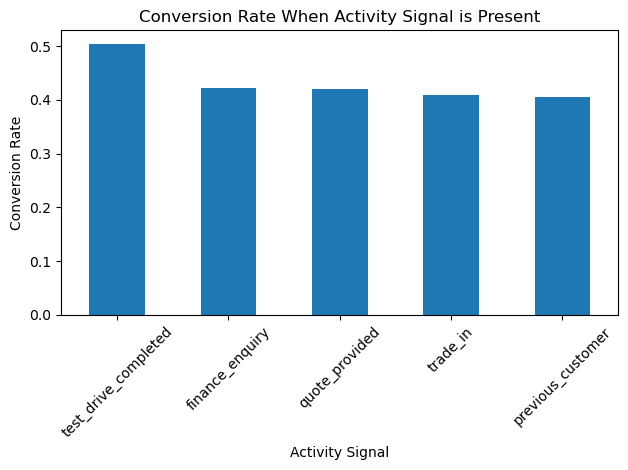

In [12]:
activity_conversion.plot(kind="bar")

plt.title("Conversion Rate When Activity Signal is Present")
plt.xlabel("Activity Signal")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Response Time and Conversion

Fast response times are usually important in sales environments because customers may contact multiple dealerships at once.

In [13]:
df["response_time_band"] = pd.cut(
    df["response_time_hours"],
    bins=[0, 2, 6, 12, 24, 100],
    labels=["0-2 hrs", "2-6 hrs", "6-12 hrs", "12-24 hrs", "24+ hrs"]
)

response_time_conversion = df.groupby("response_time_band")["converted"].mean()

response_time_conversion

C:\Users\arron\AppData\Local\Temp\ipykernel_21924\828337961.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response_time_conversion = df.groupby("response_time_band")["converted"].mean()


response_time_band
0-2 hrs      0.421053
2-6 hrs      0.415730
6-12 hrs     0.367424
12-24 hrs    0.263499
24+ hrs      0.270833
Name: converted, dtype: float64

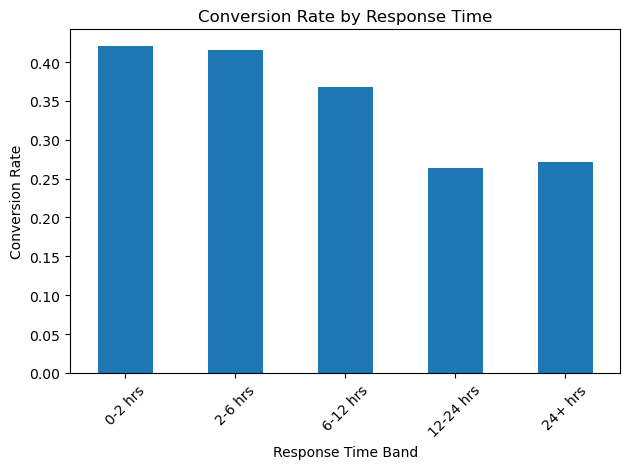

In [14]:
response_time_conversion.plot(kind="bar")

plt.title("Conversion Rate by Response Time")
plt.xlabel("Response Time Band")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Follow-up Count and Conversion

This section explores whether leads with more salesperson follow-ups are more likely to convert.

In [15]:
df["follow_up_band"] = pd.cut(
    df["follow_up_count"],
    bins=[-1, 1, 3, 5, 20],
    labels=["0-1", "2-3", "4-5", "6+"]
)

follow_up_conversion = df.groupby("follow_up_band")["converted"].mean()

follow_up_conversion

C:\Users\arron\AppData\Local\Temp\ipykernel_21924\4154172070.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  follow_up_conversion = df.groupby("follow_up_band")["converted"].mean()


follow_up_band
0-1    0.297297
2-3    0.329803
4-5    0.371859
6+     0.413793
Name: converted, dtype: float64

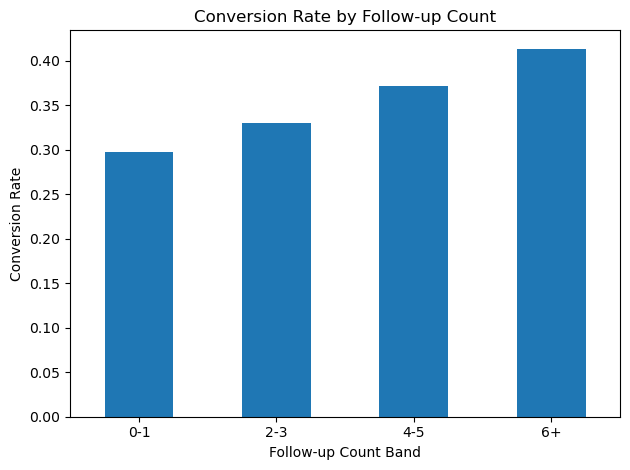

In [16]:
follow_up_conversion.plot(kind="bar")

plt.title("Conversion Rate by Follow-up Count")
plt.xlabel("Follow-up Count Band")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Key Findings

Based on the exploratory analysis:

- Referral and walk-in leads show stronger conversion potential than lower-intent digital channels.
- Test drive completion is one of the clearest buying-intent signals.
- Finance enquiries, trade-in interest and quote requests are associated with higher conversion rates.
- Faster response times generally support stronger conversion outcomes.
- Follow-up activity helps identify engaged leads, but excessive follow-ups may also indicate difficult-to-convert customers.

These insights will guide the feature selection and modelling approach in the next notebook.